<a href="https://colab.research.google.com/github/ariandit/user_arian/blob/master/otomatisasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Text preprocessing
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Optional visualization
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("complaints.csv")
print(df.head())
print("\nKolom dataset:")
print(df.columns)
print("\nJumlah data:", df.shape)

   Unnamed: 0           product  \
0           0       credit_card   
1           1       credit_card   
2           2    retail_banking   
3           3  credit_reporting   
4           4  credit_reporting   

                                           narrative  
0  purchase order day shipping amount receive pro...  
1  forwarded message date tue subject please inve...  
2  forwarded message cc sent friday pdt subject f...  
3  payment history missing credit report speciali...  
4  payment history missing credit report made mis...  

Kolom dataset:
Index(['Unnamed: 0', 'product', 'narrative'], dtype='object')

Jumlah data: (162421, 3)


In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()
    return text

df['clean_text'] = df['narrative'].astype(str).apply(clean_text)

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]
    return " ".join(words)

df['clean_text'] = df['clean_text'].apply(remove_stopwords)

In [ ]:
# Ambil kolom teks dan label
df = df[['narrative', 'product']]

# Hapus data kosong
df = df.dropna()

# Rename biar rapi
df.columns = ['text', 'label']

# Cleaning sederhana
import re
import string

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

df['text'] = df['text'].apply(clean_text)

In [ ]:
#TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['text'])
y = df['label']

In [ ]:
#Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Naive Bayes
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

In [ ]:
#svm
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

In [ ]:
#Evaluasi Model
def evaluate_model(y_test, y_pred, model_name):
    print(f"\n=== {model_name} ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average='weighted'))
    print("Recall:", recall_score(y_test, y_pred, average='weighted'))
    print("F1-Score:", f1_score(y_test, y_pred, average='weighted'))
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

In [ ]:
#evaluasi
evaluate_model(y_test, y_pred_nb, "Naive Bayes")
evaluate_model(y_test, y_pred_svm, "Support Vector Machine")


=== Naive Bayes ===
Accuracy: 0.8365298771665178
Precision: 0.8356111730942186
Recall: 0.8365298771665178
F1-Score: 0.8329630973182331

Classification Report:

                     precision    recall  f1-score   support

        credit_card       0.74      0.72      0.73      3132
   credit_reporting       0.87      0.91      0.89     18283
    debt_collection       0.82      0.59      0.69      4615
mortgages_and_loans       0.76      0.85      0.80      3770
     retail_banking       0.83      0.86      0.84      2683

           accuracy                           0.84     32483
          macro avg       0.80      0.78      0.79     32483
       weighted avg       0.84      0.84      0.83     32483


=== Support Vector Machine ===
Accuracy: 0.8694701844041499
Precision: 0.8676681271992789
Recall: 0.8694701844041499
F1-Score: 0.868083695041563

Classification Report:

                     precision    recall  f1-score   support

        credit_card       0.79      0.77      0.78    

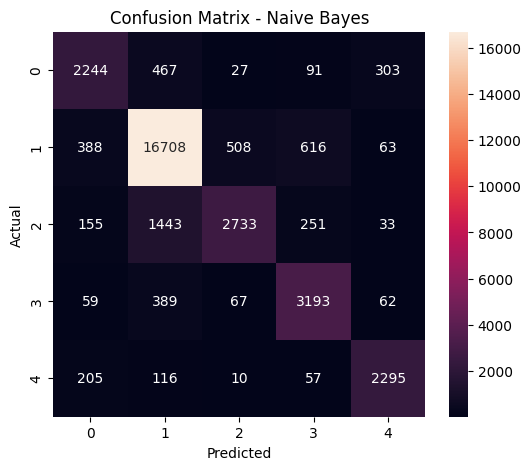

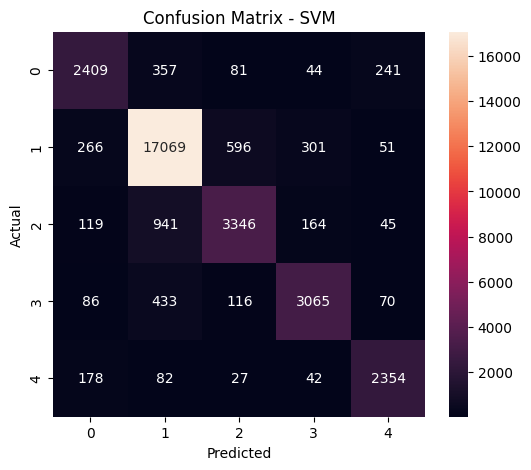

In [ ]:
#cofusion matrix
def plot_confusion_matrix(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusion_matrix(y_test, y_pred_nb, "Naive Bayes")
plot_confusion_matrix(y_test, y_pred_svm, "SVM")

In [ ]:
#perbandingan akhir
results = pd.DataFrame({
    "Model": ["Naive Bayes", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_nb, average='weighted'),
        f1_score(y_test, y_pred_svm, average='weighted')
    ]
})

print(results)

         Model  Accuracy  F1-Score
0  Naive Bayes   0.83653  0.832963
1          SVM   0.86947  0.868084
